In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from PropGen.GAN import GAN
from PropGen.BladeDictGenerator import generate_blade_dict
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
import scienceplots

plt.style.use(['science', 'no-latex'])

In [10]:
gan = GAN(latent_dim=4, noise_dim=0)
gan.load_checkpoint('N:/Teams/Groups/ThermalSim/Projects/Public/AirfoilGAN Models/WGAN_LCR1/latent4_noise0/checkpoint_50000.pth')

r_hub = 0.02794
r_tip = 0.127
n_blades = 2

# Random root and tip latent vectors (same for all parametrizations)
np.random.seed(42)
root_latent = np.random.randn(gan.latent_dim)
tip_latent = np.random.randn(gan.latent_dim)

Successfully loaded checkpoint from step 50000


In [11]:
import time

x = np.array([5.02943264e-01, 6.64959385e-02, 7.66835209e-01, 2.52184857e-01,
        6.21649488e-01, 2.65749249e-01, 6.70931606e-01, 1.01458536e-01,
        2.96178889e-02, 7.12442732e+00, 9.26211526e-03, 1.88402053e-02,
        2.70497989e+01, 4.59103735e-01, 7.91479577e+00])

n_sections_range = [5, 10, 15, 20, 30, 40, 50, 75, 100]
thrust_values = []
torque_values = []
time_values = []

print('Running convergence analysis...')
for n_sec in n_sections_range:
    print(f'  n_sections = {n_sec}', end='', flush=True)

    blade_dict = generate_blade_dict(
        x=x,
        parametrization='parametric',
        gan=gan,
        r_hub=r_hub,
        r_tip=r_tip,
        n_sections=n_sec,
        n_blades=n_blades
    )
    
    # Create propeller and run BEMT
    params = LowFidelityParameters(
        rpm=7000,
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=int(blade_dict['n_blades']),
        p_ref=2e-5,
        revolutions=5,
        num_obs_times_per_rev=100,
        device='cpu',
    )
    
    propeller = Propeller(
        geometry=blade_dict,
        params=params,
    )
    
    t_start = time.time()
    propeller.run_bemt(v_inf=0)
    T, Q, _, _ = propeller.compute_total_forces()
    t_end = time.time()
    elapsed_time = t_end - t_start
    
    thrust_values.append(T)
    torque_values.append(Q)
    time_values.append(elapsed_time)
    print(f' -> T = {T:.3f} N, Q = {Q:.3f} N·m, t = {elapsed_time:.3f} s')

print('Done!')

Running convergence analysis...
  n_sections = 5 -> T = 7.299 N, Q = 0.105 N·m, t = 0.091 s
  n_sections = 10 -> T = 7.807 N, Q = 0.112 N·m, t = 0.185 s
  n_sections = 15 -> T = 7.935 N, Q = 0.114 N·m, t = 0.287 s
  n_sections = 20 -> T = 7.991 N, Q = 0.115 N·m, t = 0.382 s
  n_sections = 30 -> T = 8.036 N, Q = 0.116 N·m, t = 0.586 s
  n_sections = 40 -> T = 8.055 N, Q = 0.116 N·m, t = 0.743 s
  n_sections = 50 -> T = 8.066 N, Q = 0.116 N·m, t = 0.927 s
  n_sections = 75 -> T = 8.076 N, Q = 0.117 N·m, t = 1.461 s
  n_sections = 100 -> T = 8.083 N, Q = 0.117 N·m, t = 1.981 s
Done!


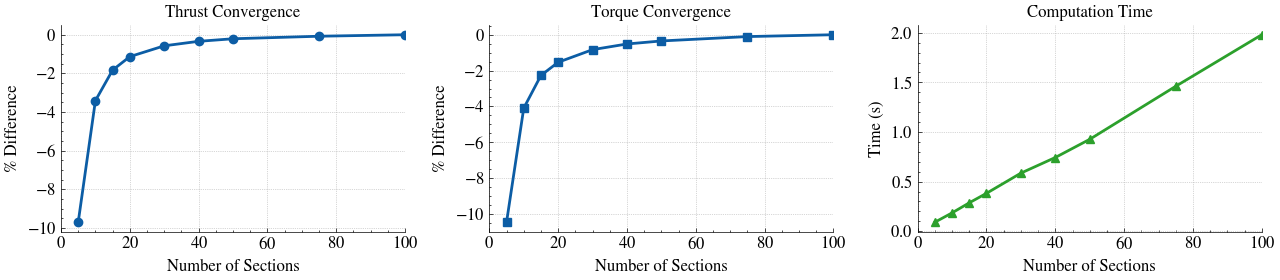


--- Summary ---
n_sections: [5, 10, 15, 20, 30, 40, 50, 75, 100]
Thrust (N):        [7.29884861 7.80702341 7.93484002 7.99103557 8.03627148 8.05506793
 8.0657656  8.07635259 8.08257945]
Thrust % diff:     [-9.69654361 -3.40925873 -1.8278748  -1.13260724 -0.57293553 -0.34038049
 -0.20802587 -0.07704058  0.        ]
Torque (N·m):      [0.10460774 0.11203812 0.11417187 0.11502825 0.11585035 0.11621899
 0.11641652 0.11670155 0.11682148]
Torque % diff:     [-10.45505012  -4.09459487  -2.2680828   -1.53501791  -0.83129583
  -0.51573872  -0.34665092  -0.1026661    0.        ]
Time (s):          [0.09123516 0.18520331 0.2866559  0.38230872 0.58587098 0.74323273
 0.92654753 1.46118522 1.98052764]


In [18]:
# Plot convergence
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

# Calculate reference values at 100 sections (last value)
thrust_ref = thrust_values[-1]
torque_ref = torque_values[-1]

# Calculate percentage differences
thrust_pct = (np.array(thrust_values) - thrust_ref) / thrust_ref * 100
torque_pct = (np.array(torque_values) - torque_ref) / torque_ref * 100

# Thrust convergence
ax = axes[0]
ax.plot(n_sections_range, thrust_pct, 'o-', linewidth=2, markersize=6)
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.set_title('Thrust Convergence', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

# Torque convergence
ax = axes[1]
ax.plot(n_sections_range, torque_pct, 's-', linewidth=2, markersize=6)
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.set_title('Torque Convergence', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

# Computation time
ax = axes[2]
ax.plot(n_sections_range, time_values, '^-', linewidth=2, markersize=6, color='tab:green')
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Computation Time', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('Figures/section_convergence.pdf', dpi=200)
plt.show()

# Print summary
print('\n--- Summary ---')
print(f'n_sections: {n_sections_range}')
print(f'Thrust (N):        {np.array(thrust_values)}')
print(f'Thrust % diff:     {thrust_pct}')
print(f'Torque (N·m):      {np.array(torque_values)}')
print(f'Torque % diff:     {torque_pct}')
print(f'Time (s):          {np.array(time_values)}')